#### Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
order_level = pd.read_parquet("data/processed/order_level.parquet")

# Filter to delivered orders with valid timestamps, consistent with prior notebooks
df = order_level[
    (order_level["is_delivered"]) & (~order_level["is_invalid_timestamps"])
].copy()

#### Overall ETA Error
* eta_error > 0: delivered later than estimated (ETA too optimistic)
* eta_error < 0: delivered earlier than estimated (ETA too conservative)

In [4]:
df["eta_error"] = df["delivery_time"] - df["estimated_delivery_time"]
df["eta_error"].describe()

count    95103.000000
mean       -11.230813
std         10.211859
min       -146.000000
25%        -16.000000
50%        -12.000000
75%         -7.000000
max        189.000000
Name: eta_error, dtype: float64

#### Overall pattern
Median ETA error is **-12 days** — Olist's ETA estimates are, on average, quite conservative (built-in buffer), which is why the platform-wide late rate is low (~6.8%).

#### ETA calibration by state

In [5]:
eta_by_state = (
    df.groupby("customer_state")
    .agg(
        avg_eta_error=("eta_error", "mean"),
        late_rate=("is_late", "mean"),
        avg_review=("review_score", "mean"),
        n_orders=("order_id", "nunique"),
    )
    .query("n_orders >= 30")  # exclude states with too few orders to avoid noisy averages
    .sort_values("avg_eta_error", ascending=False)
)

eta_by_state.head(10)

,avg_eta_error,late_rate,avg_review,n_orders
customer_state,,,,
AL,-8.374046,0.211196,3.866667,393
MA,-8.941844,0.177305,3.835714,705
SE,-9.408408,0.153153,3.906627,333
ES,-9.850610,0.108232,4.078270,1968
CE,-10.096825,0.139683,3.943381,1260
BA,-10.161682,0.121807,3.927427,3210
MS,-10.392241,0.097701,4.158501,696
SP,-10.441705,0.045453,4.243776,39909
PI,-10.586354,0.140725,4.002155,469


#### By state
- States with the **least ETA buffer** (least negative error) — AL (-8.4), MA (-8.9), SE (-9.4) — are exactly the same states with the **highest late rates** (21%, 17.7%, 15.3%) and lowest reviews. This confirms Northeast Brazil's CX problem is largely an **ETA calibration issue**, not just raw shipping distance.
- SP, despite huge volume (39,909 orders), has a similar buffer (-10.4) to lower-volume states but the lowest late rate (4.5%) — logistics infrastructure there absorbs the same nominal buffer far more reliably.

#### ETA calibration by seller

In [9]:
item_level = pd.read_parquet("data/processed/item_level.parquet")

item_df = item_level[
    (item_level["order_status"] == "delivered") & (~item_level["is_invalid_timestamps"])
].copy()

item_df["eta_error"] = (
    item_df["order_delivered_customer_date"] - item_df["order_purchase_timestamp"]
).dt.days - (
    item_df["order_estimated_delivery_date"] - item_df["order_purchase_timestamp"]
).dt.days

eta_by_seller = (
    item_df.groupby("seller_id")
    .agg(
        avg_eta_error=("eta_error", "mean"),
        late_rate=("eta_error", lambda x: (x > 0).mean()),
        avg_review=("review_score", "mean"),
        n_orders=("order_id", "nunique"),
    )
    .query("n_orders >= 30")
    .sort_values("avg_eta_error", ascending=False)
)

eta_by_seller.head(10)

,avg_eta_error,late_rate,avg_review,n_orders
seller_id,,,,
2a1348e9addc1af5aaa619b1a3679d6b,1.274510,0.294118,3.040000,48
54965bbe3e4f07ae045b90b0b8541f52,-1.303797,0.329114,3.013514,71
ede0c03645598cdfc63ca8237acbe73d,-3.404255,0.340426,3.666667,43
a49928bcdf77c55c6d6e05e09a9b4ca5,-3.836538,0.221154,2.971154,96
d13e50eaa47b4cbe9eb81465865d8cfc,-4.151515,0.136364,4.803030,64
cac4c8e7b1ca6252d8f20b2fc1a2e4af,-4.308642,0.222222,3.550000,73
6ec1a01e866584bb679eb9b098345919,-4.322581,0.225806,4.241379,30
835f0f7810c76831d6c7d24c7a646d4d,-5.041667,0.291667,3.312500,42
d20b021d3efdf267a402c402a48ea64b,-5.272727,0.181818,3.653061,84


#### Correlation: ETA error vs late rate vs review, by state

               avg_eta_error  late_rate  avg_review
avg_eta_error       1.000000   0.675321   -0.426097
late_rate           0.675321   1.000000   -0.876425
avg_review         -0.426097  -0.876425    1.000000


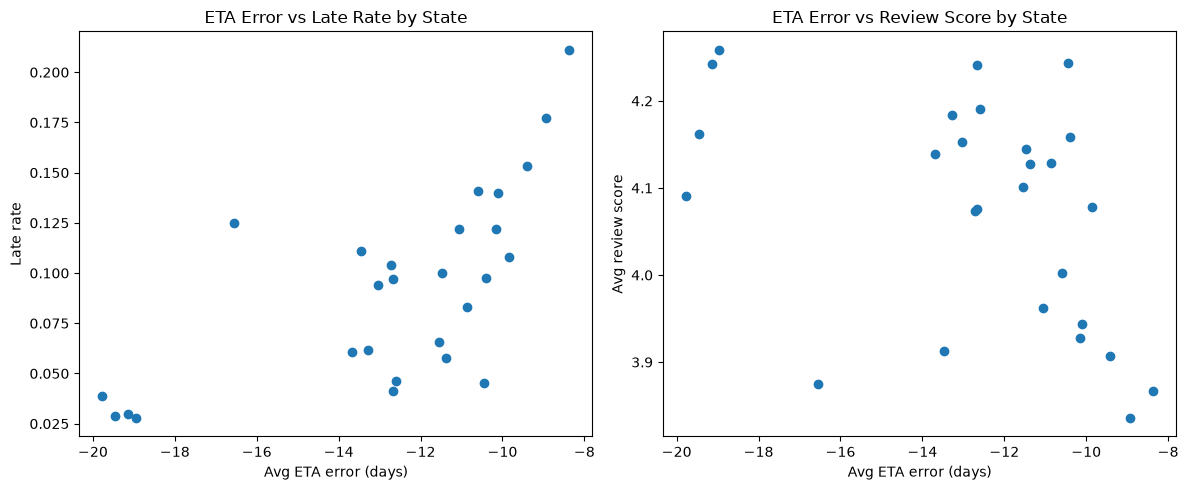

In [10]:
print(eta_by_state[["avg_eta_error", "late_rate", "avg_review"]].corr())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(eta_by_state["avg_eta_error"], eta_by_state["late_rate"])
axes[0].set_xlabel("Avg ETA error (days)")
axes[0].set_ylabel("Late rate")
axes[0].set_title("ETA Error vs Late Rate by State")

axes[1].scatter(eta_by_state["avg_eta_error"], eta_by_state["avg_review"])
axes[1].set_xlabel("Avg ETA error (days)")
axes[1].set_ylabel("Avg review score")
axes[1].set_title("ETA Error vs Review Score by State")

plt.tight_layout()
plt.show()

#### Correlation takeaways
- `eta_error` vs `late_rate` = **0.675** — less buffer → more late deliveries
- `eta_error` vs `avg_review` = **-0.426** — less buffer → lower reviews
- Weaker than the late_rate ↔ review correlation (-0.876) seen earlier, meaning ETA buffer explains part but not all of the review gap.

#### Cross-reference with previously flagged risk sellers

In [11]:
risk_sellers = pd.read_parquet("data/processed/risk_sellers.parquet")

eta_risk_overlap = eta_by_seller.merge(
    risk_sellers, left_index=True, right_index=True, how="inner", suffixes=("", "_risk")
)
print(f"Sellers appearing in both risk list and top ETA-error list: {len(eta_risk_overlap)}")
eta_risk_overlap.head(10)

Sellers appearing in both risk list and top ETA-error list: 14


,avg_eta_error,late_rate,avg_review,n_orders,total_revenue,n_orders_risk,avg_review_risk
seller_id,,,,,,,
54965bbe3e4f07ae045b90b0b8541f52,-1.303797,0.329114,3.013514,71,10169.90,71,3.013514
8e6d7754bc7e0f22c96d255ebda59eba,-5.751938,0.124031,2.992248,84,14107.38,84,2.992248
1ca7077d890b907f89be8c954a02686a,-6.330709,0.173228,2.269841,108,12474.64,108,2.269841
82e0a475a88cc9595229d8029273f045,-7.645570,0.063291,3.493671,41,10748.02,41,3.493671
897060da8b9a21f655304d50fd935913,-9.060976,0.121951,3.482759,302,21655.61,302,3.482759
712e6ed8aa4aa1fa65dab41fed5737e4,-9.105882,0.211765,3.464286,77,39385.00,77,3.464286
2eb70248d66e0e3ef83659f71b244378,-9.497462,0.137056,2.809278,187,38990.72,187,2.809278
c60b801f2d52c7f7f91de00870882a75,-10.153846,0.153846,3.435897,39,11296.50,39,3.435897
88460e8ebdecbfecb5f9601833981930,-10.222222,0.188552,3.351351,243,31080.70,243,3.351351


#### Seller overlap with risk list
14 of the 18 previously flagged risk sellers also show tight/negative ETA buffers — this cross-validates the earlier risk-seller list using an independent signal (ETA calibration, not just review score), strengthening confidence in that list rather than adding new names.

Top overlap:
- `7c67e1448b...` — buffer -10.9 days, late rate 9.2%, review 3.35
- `2eb70248...` — buffer -9.5 days, late rate 13.7%, review 2.81

#### Key Takeaway
ETA buffer size — not just physical distance — is a **controllable lever** behind the Northeast's poor delivery experience. States/sellers with thin buffers show both higher late rates and lower reviews, and this pattern already flags most of the previously identified risk sellers independently.

#### Recommended action
Widen ETA buffers specifically for Northeast states (AL, MA, SE, CE, BA, PI) and for sellers with tight/negative buffers — a low-cost fix (adjusting an estimate, not fixing physical logistics) that directly targets the mechanism shown to hurt reviews most.